# Conversion Rate Analysis

This notebook performs a comprehensive analysis of conversion rates derived from a marketing campaign dataset. It calculates the overall conversion rate and further examines conversion rates across various customer segments. The analysis also delves into the daily conversion rates for different customer categories. Finally, it presents key findings through effective data visualizations.

**Key Analyses Performed:**

1.  **Overall Conversion Rate:** Determination of the overall success rate of the marketing campaign.
2.  **Customer Segmentation:** Analysis of conversion rates across different customer categories based on the following:
    *   Marketing Channel
    *   Variant (A/B Test Group)
    *   Language Displayed
    *   Preferred Language
    *   Age Group
    *   Subscribing Channel
3.  **Daily Conversion Rate:** Examination of daily conversion rate trends, broken down by customer segments.
4.  **Data Visualization:** Creation of clear and informative visualizations to present the results of the analysis.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read marketing data from CSV, parse dates
marketing = pd.read_csv("/content/drive/MyDrive/Marketing Analytics in Python\
/Analysing Marketing Campaigns with python\
/marketing.csv",
parse_dates=['date_served', 'date_subscribed', 'date_canceled'],
date_format='%m/%d/%y')

## Calculating Overall Conversation Rate


In [3]:
# Calculate the number of people we marketed to
total = marketing['user_id'].nunique()
print(total)

# Calculate the number of people who subscribed
subscribers = marketing[marketing['converted']==True]['user_id'].nunique()
print(subscribers)

# Calculate the conversion rate
conversion_rate = subscribers / total
print(round(conversion_rate*100, 2), "%")

7309
1015
13.89 %


*Out of 7309 people marketed to, 1015 subscribed, resulting in an overall conversion rate of 13.89%*












## Customer Segmentation
- Analysing Conversion Rate across categories : `marketing_channel`, `variant`, `language_displayed`, `language_preferred`, `age_group`, `subscribing_channel`

In [4]:
def conversion_rate(dataframe, column_names):
    # Total number of converted users
    column_conv = dataframe[dataframe['converted']==True].groupby(column_names)['user_id'].nunique()

    # Total number users
    column_total = dataframe.groupby(column_names)['user_id'].nunique()

    # Conversion rate
    conversion_rate = column_conv/column_total

    # Fill missing values with 0
    conversion_rate = round(conversion_rate, 2)*100
    return conversion_rate

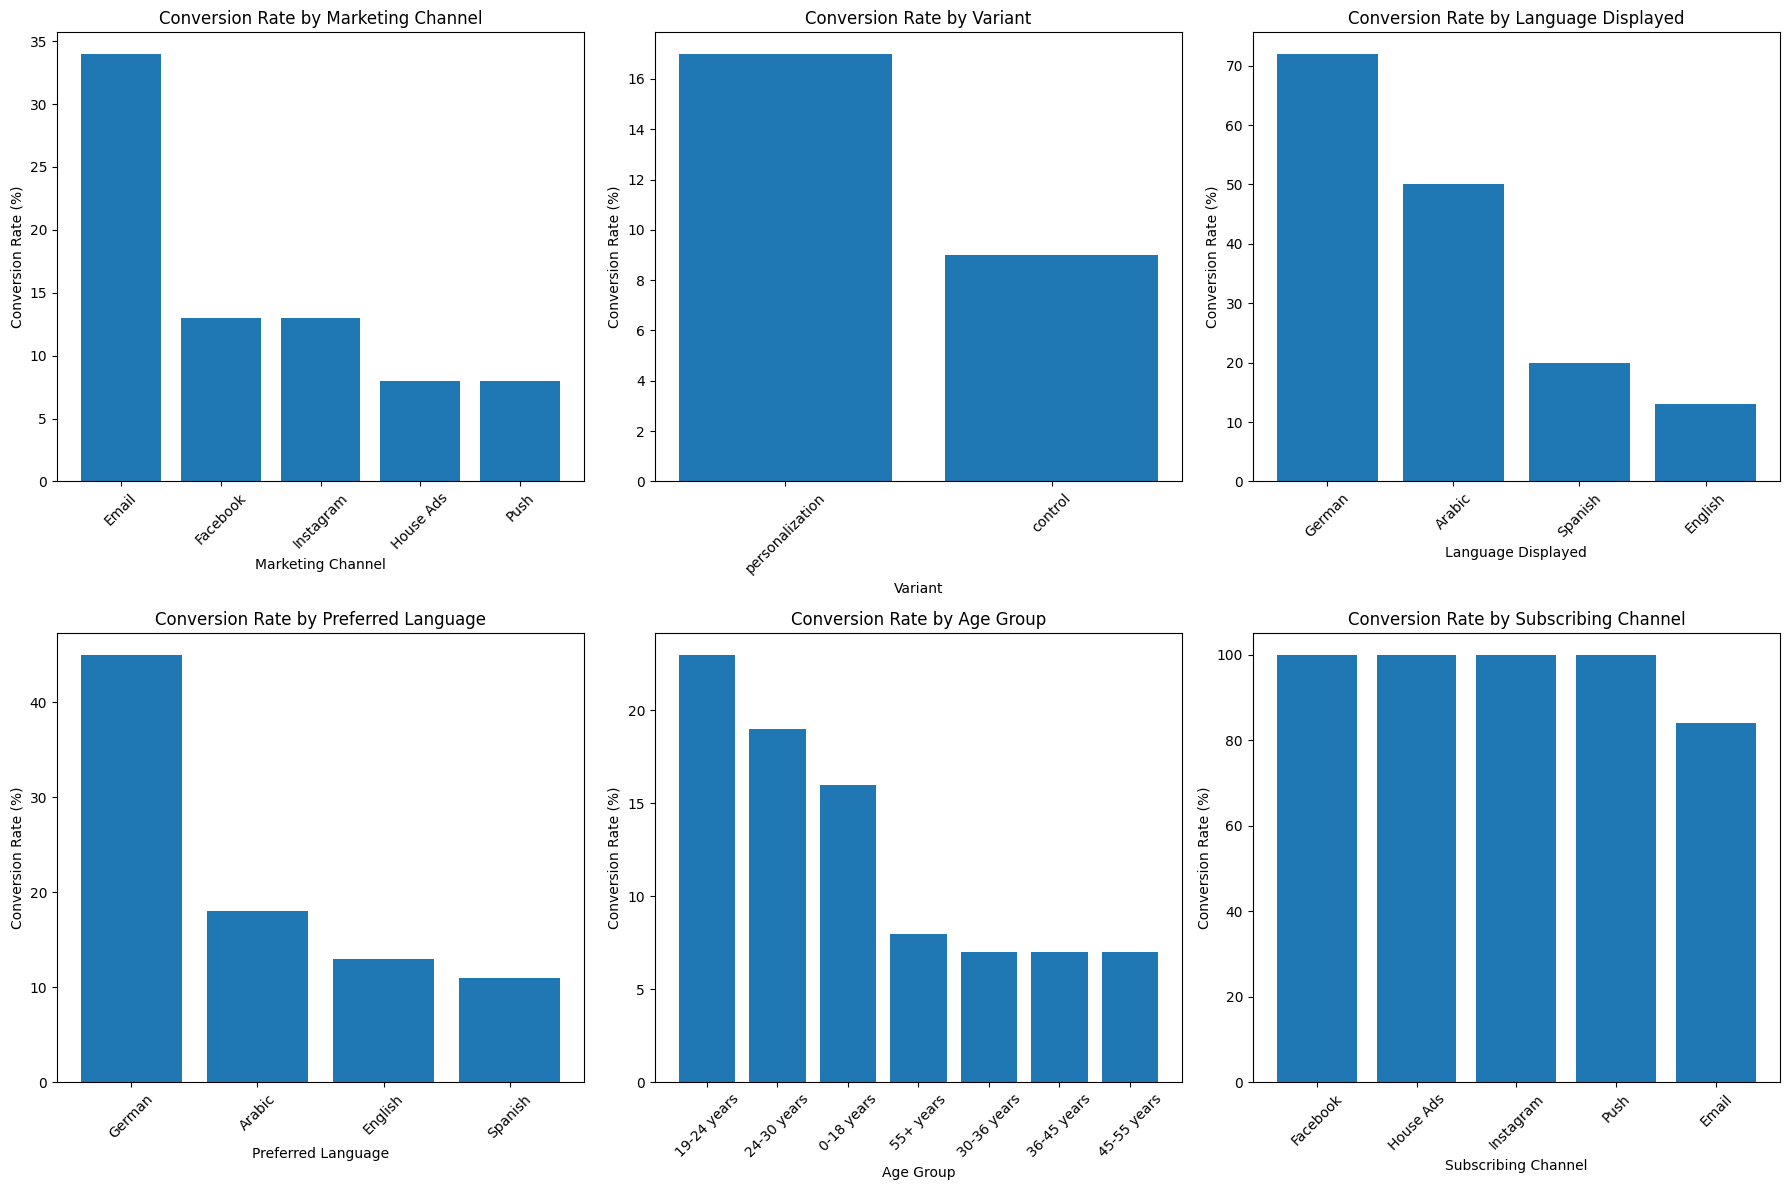

In [5]:
# Columns for conversion rate calculation
columns_to_check = ['marketing_channel', 'variant', 'language_displayed', 'language_preferred', 'age_group', 'subscribing_channel']
professional_labels = {
    'marketing_channel': 'Marketing Channel',
    'variant': 'Variant',
    'language_displayed': 'Language Displayed',
    'language_preferred': 'Preferred Language',
    'age_group': 'Age Group',
    'subscribing_channel': 'Subscribing Channel'
}

# Set up the subplot grid: 2 rows, 3 columns (since we have 6 columns to check)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Flatten axes array for easier iteration
axes = axes.flatten()

# Calculate and visualize conversion rate for each column
convertion_rates = {}
for i, column in enumerate(columns_to_check):
    convertion_rate = conversion_rate(marketing, column).sort_values(ascending=False) # Assuming this is a function you have
    convertion_rates[column] = convertion_rate

    # Visualize the conversion rate in subplots
    axes[i].bar(convertion_rate.index, convertion_rate.values, color='tab:blue')
    axes[i].set_title(f'Conversion Rate by {professional_labels[column]}')
    axes[i].set_ylabel('Conversion Rate (%)')
    axes[i].set_xlabel(professional_labels[column])
    axes[i].tick_params(axis='x', rotation=45)

# Adjust layout to avoid overlapping elements
plt.tight_layout()
plt.savefig('conversion_rate_by_category.png')
plt.show()

The visualizations display insights into conversion rates across various categories:

1. **Marketing Channel**: Email has the highest conversion rate (35%), significantly outperforming other channels like Facebook, Instagram, and Push, which hover around 10% or less.

2. **Variant**: The personalization variant shows a much higher conversion rate (16%) compared to the control group (7%).

3. **Language Displayed**: German leads with a very high conversion rate (70%), followed by Arabic (50%), while Spanish and English have much lower rates (10%).

4. **Preferred Language**: German also dominates as the preferred language (40%), while others like Arabic, English, and Spanish have lower rates (10–15%).

5. **Age Group**: Younger audiences (19-24 years and 24-30 years) show the highest conversion rates (20%), while older groups (35+ years) convert less (5–10%).

6. **Subscribing Channel**: Most channels, including Facebook, House Ads, Instagram, and Push, have near-perfect conversion rates (100%), except for Email (80%).


## Analysis of Daily Conversion Rate

In [6]:
def plotting_conv(dataframe):
    for column in dataframe:
        # Plot column by dataframe's index
        dataframe.index
        plt.plot(dataframe.index, dataframe[column])

        plt.title('Daily ' + str(column) + ' conversion rate\n',
                  size = 16)
        plt.ylabel('Conversion rate', size = 14)
        plt.xlabel('Date', size = 14)
        plt.xticks(rotation=90, ha='right')

        #plt.ylim(0, .5)
        # Show plot
        plt.show()


In [7]:
# Calculate conversion rate by date served and channel
daily_conv_channel = conversion_rate(marketing, ['date_served',
                                                 'marketing_channel'])

# Unstack daily_conv_channel and convert it to a DataFrame
daily_conv_channel = pd.DataFrame(daily_conv_channel.unstack(level = 1))
daily_conv_channel.head()

marketing_channel,Email,Facebook,House Ads,Instagram,Push
date_served,,,,,
2018-01-01,100.0,12.0,8.0,11.0,8.0
2018-01-02,100.0,10.0,8.0,13.0,6.0
2018-01-03,NaN,8.0,9.0,17.0,8.0
2018-01-04,50.0,14.0,9.0,13.0,6.0
2018-01-05,100.0,11.0,13.0,16.0,3.0


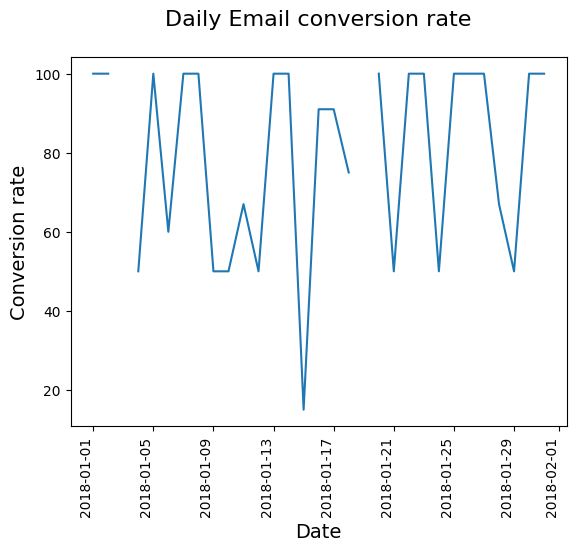

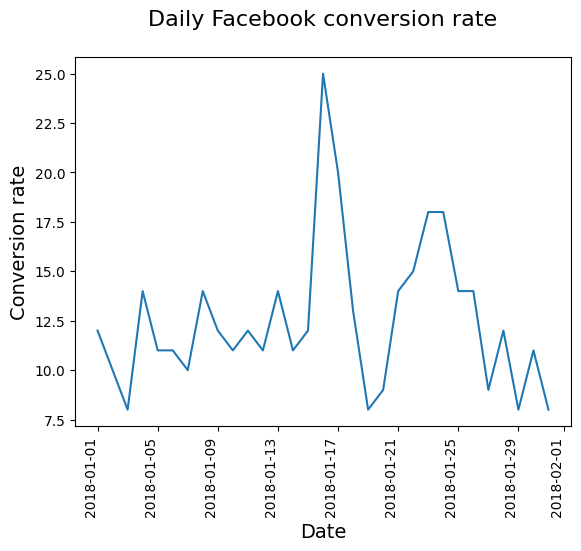

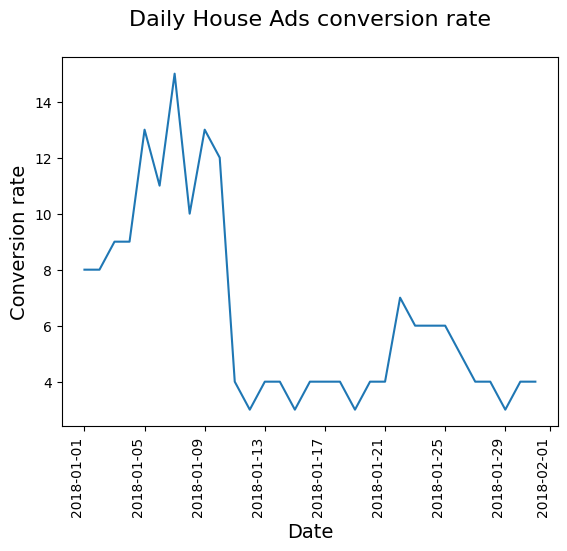

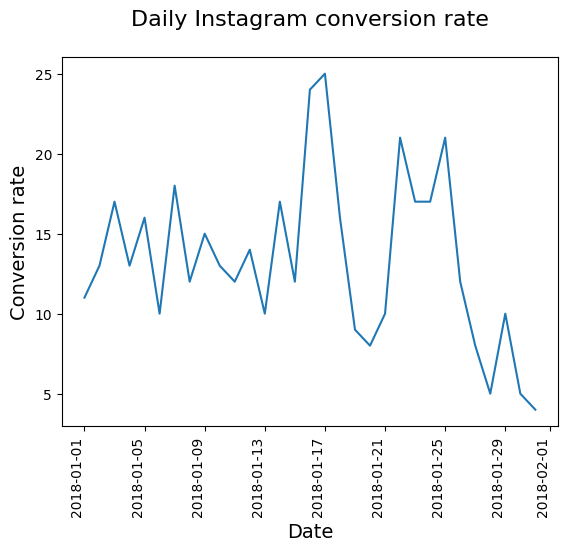

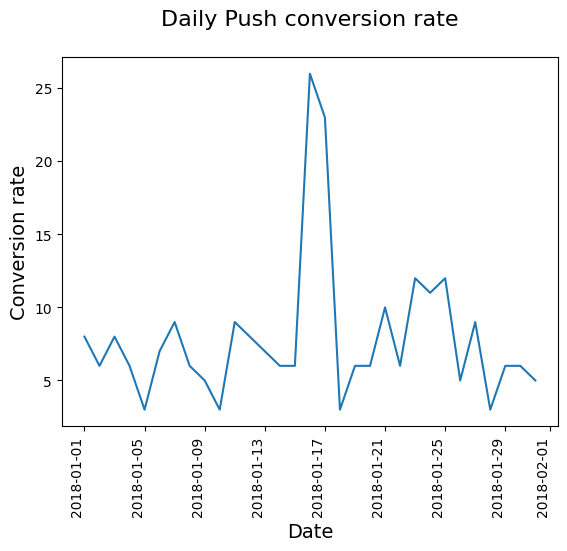

In [8]:
# Plot results of daily_conv_channel
plotting_conv(daily_conv_channel)